In [ ]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

project_root = Path(os.getcwd()).parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
SAVE_DIR = project_root / "experiments" / "cva_plots"
os.makedirs(SAVE_DIR, exist_ok=True)
from src.utils.seed import set_seed
set_seed(42)

from src.data.preprocessing.pipeline import Pipeline
from src.data.preprocessing.cva_stat import CVAAnalyzer 
from src.data.preprocessing.loss_peak_stats import LossTargetAnalyzer

NUM_CYCLE = [0, 1, 2, 3, 4]
TEST_INHIBITOR = "2-mercaptobenzimidazole"

pipe = Pipeline(
    num_cycle=NUM_CYCLE, 
    test_inhibitor=TEST_INHIBITOR, 
    norm_feat=True, 
    use_wavelet=False, 
    flip_the_peak=False
)

print(f"[*] Всего образцов в полном датасете: {len(pipe.all_voltage)}")

analyzer_all = CVAAnalyzer(pipe.all_voltage, pipe.all_current)
all_stats_df = analyzer_all.extract_statistics()

all_stats_df['ppm'] = pipe.all_metadata['ppm'].values
all_stats_df['Inhibitor'] = pipe.all_metadata['Inhibitor'].values
all_stats_df['Num_of_Cycle'] = pipe.all_metadata['Num_of_Cycle'].values
stats_with_meta = all_stats_df.copy()

[*] Всего образцов в полном датасете: 4325


[*] Общая статистика по всем извлеченным признакам:


,count,mean,std,min,25%,50%,75%,max
I_pa,4325.0,2.406940,1.618014,-0.095844,0.884370,2.625639,3.824488,6.102633
E_pa,4325.0,0.640066,0.290517,-0.000417,0.477515,0.544289,0.616482,1.265455
I_pc,4325.0,-2.767926,1.783231,-7.532810,-4.128012,-2.757623,-1.202328,0.016284
E_pc,4325.0,-0.650331,0.245447,-1.341421,-0.768322,-0.595957,-0.489842,-0.001464
Delta_E,4325.0,1.290397,0.417398,0.012911,1.014564,1.189109,1.477589,2.555803
Peak_Ratio,4324.0,0.826997,0.469905,0.000000,0.708860,0.849037,0.987895,18.000000
Q_anodic,4325.0,1.087103,0.784770,-0.034185,0.360192,1.124541,1.694137,4.013916
Q_cathodic,4325.0,1.392375,0.905693,-0.038877,0.604280,1.377679,2.062214,4.845506
Q_total,4325.0,2.479557,1.672341,-0.008358,0.965777,2.514737,3.746182,8.534668
Max_dI_dV_anodic,4325.0,22.231819,16.484050,0.053323,8.674641,21.758596,31.853539,110.075046



[*] Средние значения характеристик по ингибиторам:


,I_pa,E_pa,I_pc,E_pc,Delta_E,Peak_Ratio,Q_anodic,Q_cathodic,Q_total,Max_dI_dV_anodic,Max_dI_dV_cathodic,Half_Wave_Potential,ppm,Num_of_Cycle
Inhibitor,,,,,,,,,,,,,,
2-mercaptobenzimidazole,2.117476,0.613567,-2.612571,-0.627243,1.240811,0.788488,1.012704,1.291085,2.303837,16.162222,36.773887,-0.006838,30.051546,2.0
4-benzylpiperidine,2.386530,0.645638,-2.368432,-0.655262,1.300900,0.974764,1.016766,1.261172,2.277938,24.891053,32.902631,-0.004812,37.546296,2.0
benzimidazole,2.685695,0.658755,-3.168145,-0.651675,1.310430,0.780862,1.152137,1.535586,2.687723,27.583797,45.864979,0.003540,39.148936,2.0
benzotriazole,2.384471,0.637998,-2.869643,-0.664412,1.302411,0.765118,1.152298,1.457536,2.610106,19.256332,38.352962,-0.013207,38.000000,2.0


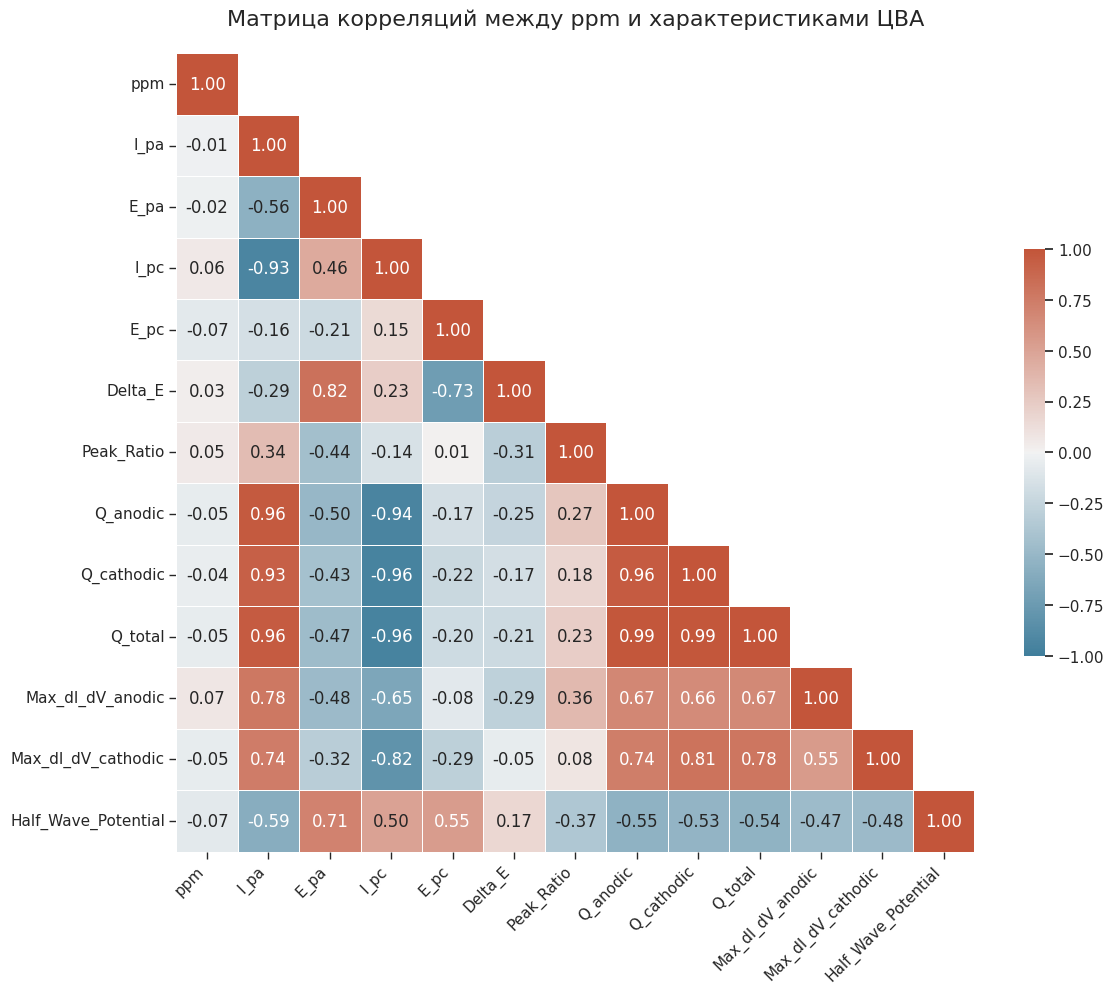

✅ Heatmap сохранен в: /mnt/c/Users/edtop/ITMO/THESIS_CV_DIFF/experiments/cva_plots/Correlation_Heatmap.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

stats_with_meta = all_stats_df.copy()

print("[*] Общая статистика по всем извлеченным признакам:")
display(stats_with_meta.drop(columns=['Inhibitor']).describe().T)

print("\n[*] Средние значения характеристик по ингибиторам:")
display(stats_with_meta.groupby('Inhibitor').mean())

numeric_cols = ['ppm', 'I_pa', 'E_pa', 'I_pc', 'E_pc', 'Delta_E', 
                'Peak_Ratio', 'Q_anodic', 'Q_cathodic', 'Q_total', 
                'Max_dI_dV_anodic', 'Max_dI_dV_cathodic', "Half_Wave_Potential"]

corr_matrix = stats_with_meta[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.set_theme(style="white")
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, 
            annot=True, fmt=".2f", ax=ax)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.title("Матрица корреляций между ppm и характеристиками ЦВА", fontsize=16, pad=20)
plt.tight_layout()

heatmap_filename = SAVE_DIR / "Correlation_Heatmap.png"
plt.savefig(heatmap_filename, dpi=300, bbox_inches='tight')
plt.show()
print(f"Heatmap сохранен в: {heatmap_filename}")

In [ ]:
features_corr = corr_matrix.drop(columns=['ppm'], index=['ppm'], errors='ignore')

corr_pairs = features_corr.unstack().reset_index()
corr_pairs.columns = ['Признак 1', 'Признак 2', 'Корреляция']

corr_pairs = corr_pairs[corr_pairs['Признак 1'] != corr_pairs['Признак 2']]

corr_pairs['Pair'] = corr_pairs.apply(lambda row: tuple(sorted([row['Признак 1'], row['Признак 2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset=['Pair']).drop(columns=['Pair'])

corr_pairs['Abs_Corr'] = corr_pairs['Корреляция'].abs()
sorted_pairs = corr_pairs.sort_values(by='Abs_Corr', ascending=False).drop(columns=['Abs_Corr'])

print("\n=================================================================")
print(" ТОП-15 СИЛЬНЕЙШИХ КОРРЕЛЯЦИЙ В ДАТАСЕТЕ (БЕЗ PPM)")
print("=================================================================\n")

print(f"{'Признак 1':<22} | {'Признак 2':<22} | {'r Пирсона':<10} | {'Интерпретация'}")
print("-" * 75)

for _, row in sorted_pairs.head(60).iterrows():
    val = row['Корреляция']
    abs_val = abs(val)
    
    if abs_val >= 0.8:
        interp = "Очень сильная 🔴"
    elif 0.6 <= abs_val < 0.8:
        interp = "Сильная 🟠"
    elif 0.4 <= abs_val < 0.6:
        interp = "Средняя 🟡"
    else:
        interp = "Слабая ⚪"
        
    print(f"{row['Признак 1']:<22} | {row['Признак 2']:<22} | {val:>9.3f} | {interp}")


 ТОП-15 СИЛЬНЕЙШИХ КОРРЕЛЯЦИЙ В ДАТАСЕТЕ (БЕЗ PPM)

Признак 1              | Признак 2              | r Пирсона  | Интерпретация
---------------------------------------------------------------------------
Q_cathodic             | Q_total                |     0.991 | Очень сильная 🔴
Q_anodic               | Q_total                |     0.988 | Очень сильная 🔴
I_pa                   | Q_anodic               |     0.964 | Очень сильная 🔴
I_pc                   | Q_total                |    -0.960 | Очень сильная 🔴
Q_anodic               | Q_cathodic             |     0.957 | Очень сильная 🔴
I_pc                   | Q_cathodic             |    -0.957 | Очень сильная 🔴
I_pa                   | Q_total                |     0.956 | Очень сильная 🔴
I_pc                   | Q_anodic               |    -0.942 | Очень сильная 🔴
I_pa                   | I_pc                   |    -0.931 | Очень сильная 🔴
I_pa                   | Q_cathodic             |     0.929 | Очень сильная 🔴
E_pa          

[*] Средние значения параметров по номерам циклов (нумерация с 1):


,I_pa,Q_anodic,Q_total
Cycle,,,
1,0.103,0.048,0.376
2,1.872,0.783,1.871
3,2.737,1.235,2.761
4,3.423,1.561,3.427
5,3.900,1.809,3.963


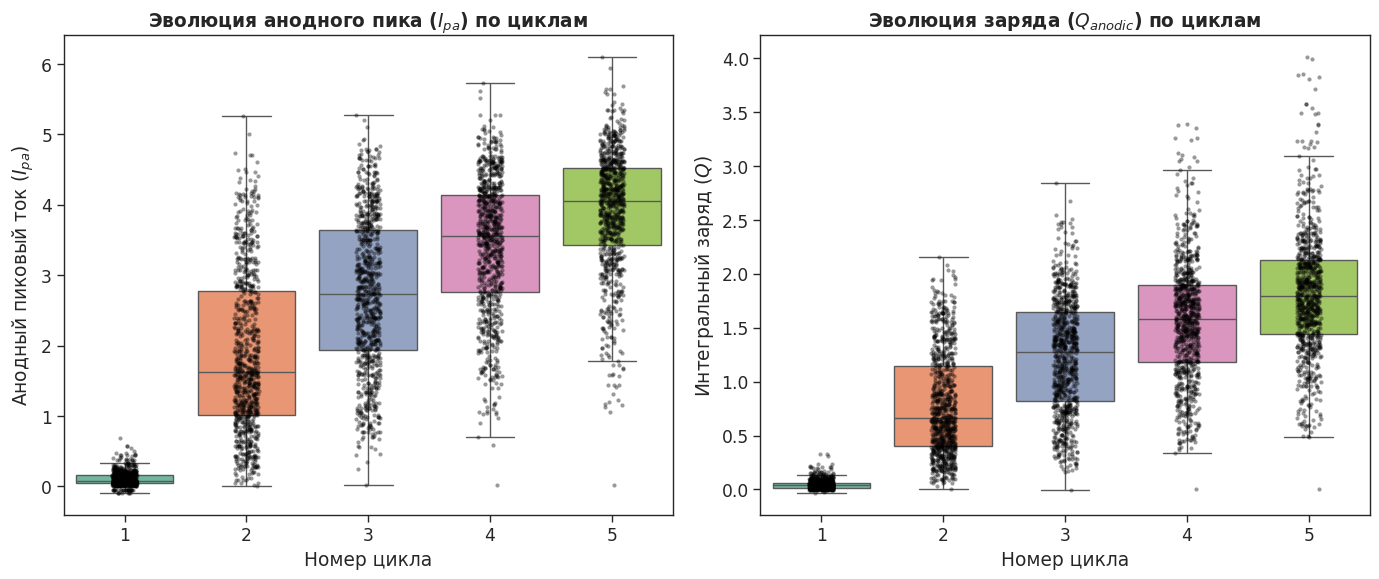

In [ ]:
df_plot = all_stats_df.copy()
df_plot['Cycle'] = df_plot['Num_of_Cycle'] + 1 

print("[*] Средние значения параметров по номерам циклов (нумерация с 1):")
cycle_stats = df_plot.groupby('Cycle')[['I_pa', 'Q_anodic', 'Q_total']].mean().round(3)
display(cycle_stats)

sns.set_context("paper", font_scale=1.4)
sns.set_style("ticks")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df_plot, x='Cycle', y='I_pa',
    hue='Cycle', legend=False,
    ax=axes[0], palette="Set2", showfliers=False
)
sns.stripplot(data=df_plot, x='Cycle', y='I_pa', ax=axes[0],
              color='black', alpha=0.4, jitter=True, size=3)
axes[0].set_title("Эволюция анодного пика ($I_{pa}$) по циклам", fontweight='bold')
axes[0].set_xlabel("Номер цикла")
axes[0].set_ylabel("Анодный пиковый ток ($I_{pa}$)")

sns.boxplot(
    data=df_plot, x='Cycle', y='Q_anodic',
    hue='Cycle', legend=False,
    ax=axes[1], palette="Set2", showfliers=False
)
sns.stripplot(data=df_plot, x='Cycle', y='Q_anodic', ax=axes[1],
              color='black', alpha=0.4, jitter=True, size=3)
axes[1].set_title("Эволюция заряда ($Q_{anodic}$) по циклам", fontweight='bold')
axes[1].set_xlabel("Номер цикла")
axes[1].set_ylabel("Интегральный заряд ($Q$)")

plt.tight_layout()
plt.savefig(SAVE_DIR / "Stats_by_Cycle.png", dpi=300, bbox_inches='tight')
plt.show()

[*] Для ингибитора '2-mercaptobenzimidazole' выбрана концентрация: 20 ppm


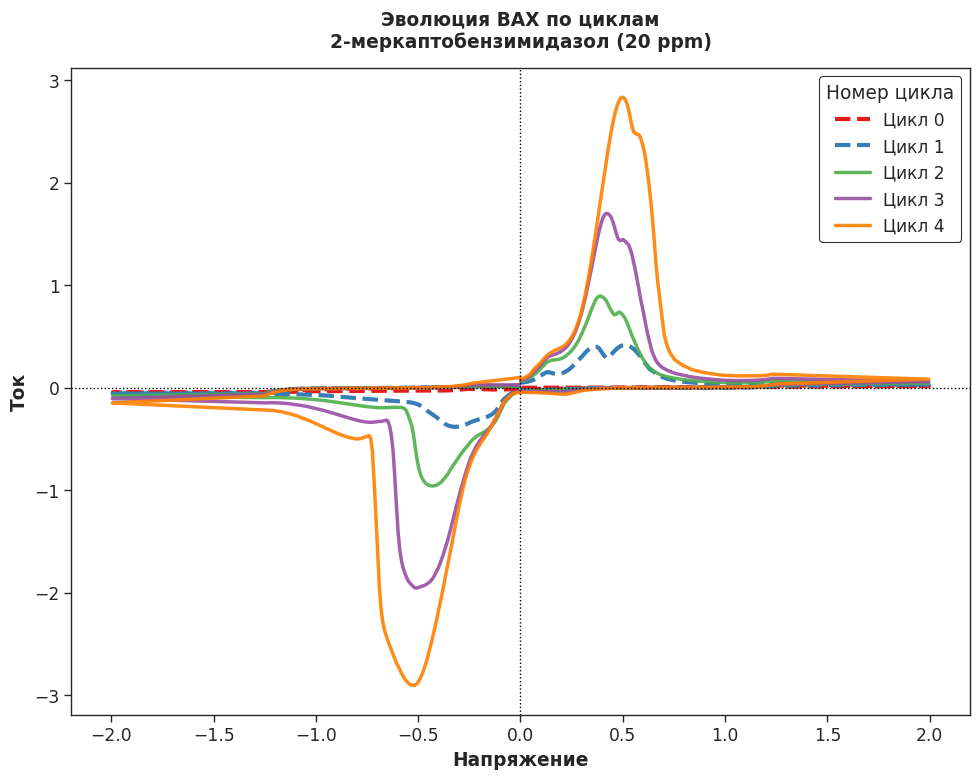

✅ График сохранен: /mnt/c/Users/edtop/ITMO/THESIS_CV_DIFF/experiments/cva_plots/All_Cycles_2-mercaptobenzimidazole_20ppm.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_single_inhibitor_all_cycles(voltage_df, current_df, metadata_df, target_inhibitor, save_dir, true_name):
    sns.set_context("paper", font_scale=1.4)
    sns.set_style("ticks")
    
    mask_inh = metadata_df['Inhibitor'] == target_inhibitor
    if not mask_inh.any():
        print(f"Ингибитор '{target_inhibitor}' не найден в данных!")
        return
        
    inh_meta = metadata_df[mask_inh]
    
    available_ppms = sorted(inh_meta['ppm'].unique())
    target_ppm = available_ppms[len(available_ppms) // 2]
    print(f"[*] Для ингибитора '{target_inhibitor}' выбрана концентрация: {target_ppm} ppm")
    
    exp_meta = inh_meta[inh_meta['ppm'] == target_ppm].copy()
    
    exp_meta = exp_meta.drop_duplicates(subset=['Num_of_Cycle']).sort_values('Num_of_Cycle')
    
    if exp_meta.empty:
        print("Нет данных для отрисовки.")
        return

    plt.figure(figsize=(10, 8))
    
    colors = sns.color_palette("Set1", n_colors=len(exp_meta))
    
    for i, (idx, row) in enumerate(exp_meta.iterrows()):
        cycle_num = int(row['Num_of_Cycle'])
        
        v = voltage_df.iloc[idx].values
        c = current_df.iloc[idx].values
        
        if cycle_num == 0 or cycle_num == 1:
            plt.plot(v, c, label=f'Цикл {cycle_num}', color=colors[i], 
                     linewidth=3, linestyle='--')
        else:
            plt.plot(v, c, label=f'Цикл {cycle_num}', color=colors[i], 
                     linewidth=2.5, alpha=0.9)

    plt.title(f"Эволюция ВАХ по циклам\n{true_name} ({target_ppm} ppm)", 
              fontweight='bold', pad=15)
    plt.xlabel("Напряжение", fontweight='bold')
    plt.ylabel("Ток", fontweight='bold')
    
    plt.axhline(0, color='black', linewidth=1, linestyle=':')
    plt.axvline(0, color='black', linewidth=1, linestyle=':')
    
    plt.legend(title="Номер цикла", loc='best', frameon=True, edgecolor='black')
    plt.tight_layout()
    
    safe_name = target_inhibitor.replace(' ', '_').replace('/', '_')
    filename = save_dir / f"All_Cycles_{safe_name}_{target_ppm}ppm.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"График сохранен: {filename}")

TARGET = "2-mercaptobenzimidazole"
INHIB_NAME1 = "бензимидазол"
INHIB_NAME2 = "бензотриазол"
INHIB_NAME3 = "2-меркаптобензимидазол"
INHIB_NAME4 = "4-бензилпиперидин"

plot_single_inhibitor_all_cycles(
    voltage_df=pipe.all_voltage, 
    current_df=pipe.all_current, 
    metadata_df=pipe.all_metadata, 
    target_inhibitor=TARGET, 
    save_dir=SAVE_DIR, 
    true_name=INHIB_NAME3
)

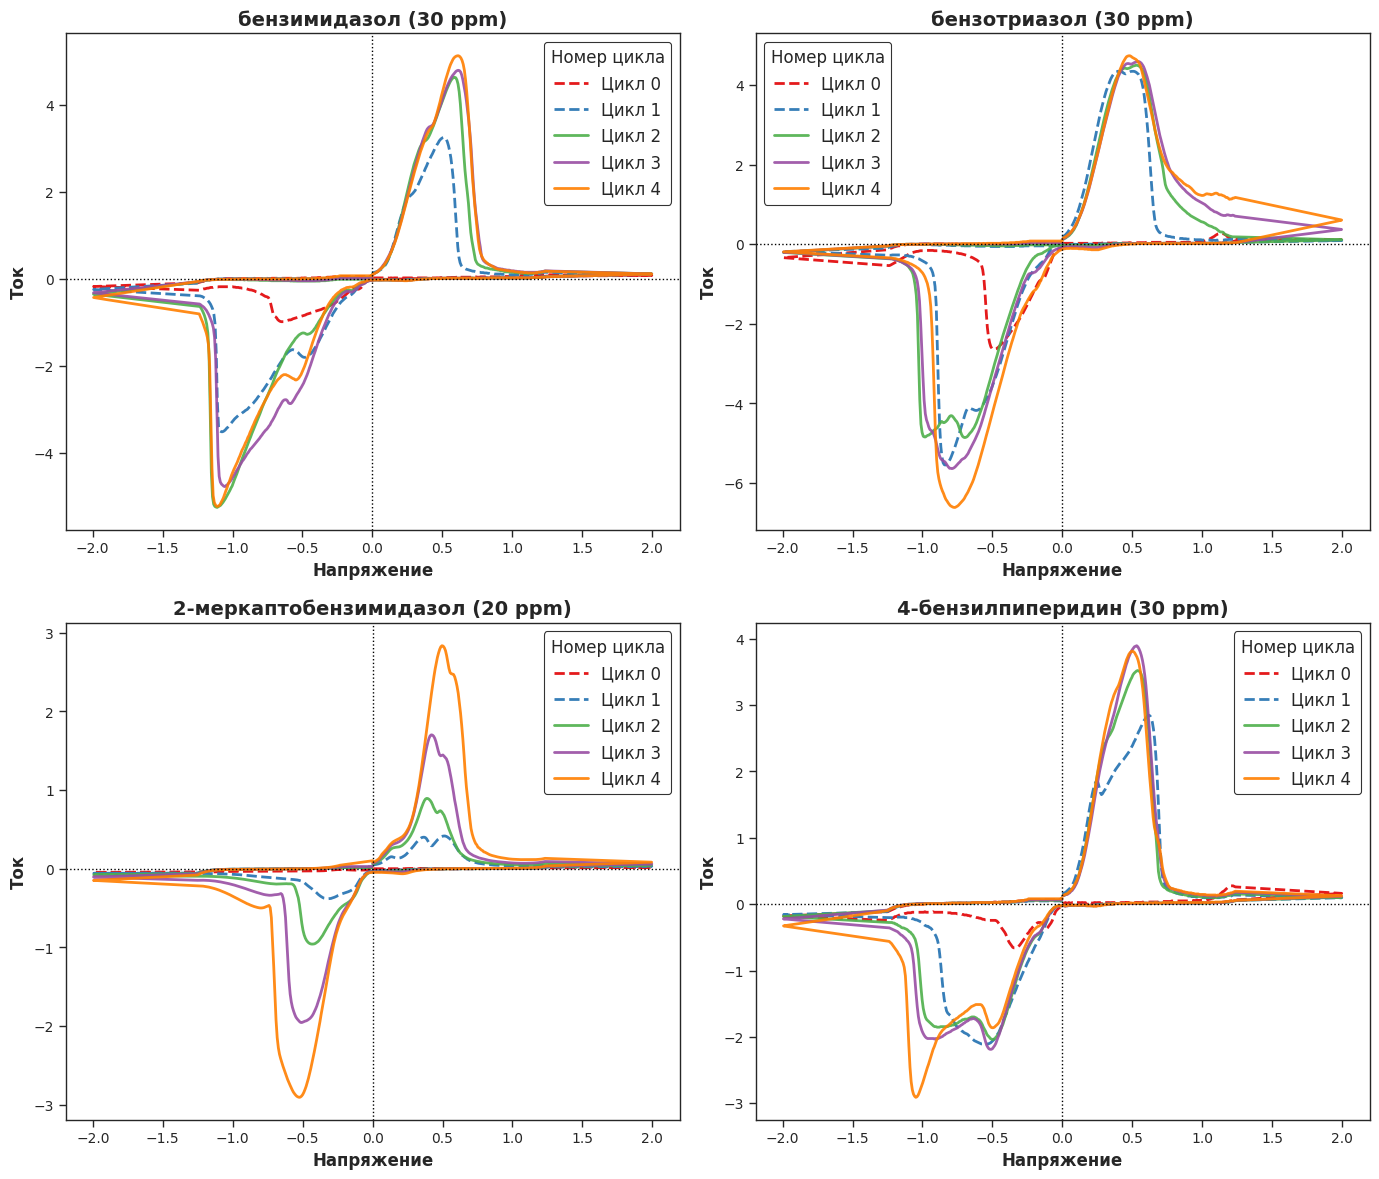

✅ Общий график сохранён: /mnt/c/Users/edtop/ITMO/THESIS_CV_DIFF/experiments/cva_plots/All_Inhibitors_Cycles_Comparison.png


In [ ]:
def plot_inhibitors_quad(voltage_df, current_df, metadata_df, 
                         inhibitors_list, true_names_dict, save_dir,
                         legend_fontsize=12, title_fontsize=14, 
                         label_fontsize=12, tick_fontsize=10):
    sns.set_context("paper", font_scale=1.4)
    sns.set_style("ticks")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for ax, target_inhibitor in zip(axes, inhibitors_list):
        mask_inh = metadata_df['Inhibitor'] == target_inhibitor
        if not mask_inh.any():
            ax.text(0.5, 0.5, f'Нет данных для\n{target_inhibitor}', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(target_inhibitor)
            continue
            
        inh_meta = metadata_df[mask_inh]
        
        available_ppms = sorted(inh_meta['ppm'].unique())
        if not available_ppms:
            ax.text(0.5, 0.5, f'Нет данных о ppm\nдля {target_inhibitor}', 
                    ha='center', va='center', transform=ax.transAxes)
            continue
        target_ppm = available_ppms[len(available_ppms) // 2]
        
        exp_meta = inh_meta[inh_meta['ppm'] == target_ppm].copy()
        
        exp_meta = exp_meta.drop_duplicates(subset=['Num_of_Cycle']).sort_values('Num_of_Cycle')
        
        if exp_meta.empty:
            ax.text(0.5, 0.5, f'Нет данных для\nконц. {target_ppm} ppm', 
                    ha='center', va='center', transform=ax.transAxes)
            continue
        
        colors = sns.color_palette("Set1", n_colors=len(exp_meta))
        for i, (idx, row) in enumerate(exp_meta.iterrows()):
            cycle_num = int(row['Num_of_Cycle'])
            v = voltage_df.iloc[idx].values
            c = current_df.iloc[idx].values
            
            if cycle_num == 0 or cycle_num == 1:
                ax.plot(v, c, label=f'Цикл {cycle_num}', color=colors[i], 
                        linewidth=2, linestyle='--')
            else:
                ax.plot(v, c, label=f'Цикл {cycle_num}', color=colors[i], 
                        linewidth=2, alpha=0.9)
        
        true_name = true_names_dict.get(target_inhibitor, target_inhibitor)
        ax.set_title(f"{true_name} ({target_ppm} ppm)", fontweight='bold', fontsize=title_fontsize)
        ax.set_xlabel("Напряжение", fontweight='bold', fontsize=label_fontsize)
        ax.set_ylabel("Ток", fontweight='bold', fontsize=label_fontsize)
        ax.axhline(0, color='black', linewidth=1, linestyle=':')
        ax.axvline(0, color='black', linewidth=1, linestyle=':')
        
        ax.legend(title="Номер цикла", loc='best', frameon=True, 
                  edgecolor='black', fontsize=legend_fontsize, 
                  title_fontsize=legend_fontsize)
        ax.tick_params(axis='both', labelsize=tick_fontsize)
    
    plt.tight_layout()
    save_path = save_dir / "All_Inhibitors_Cycles_Comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Общий график сохранён: {save_path}")

inhibitors = [
    "benzimidazole",   
    "benzotriazole",
    "2-mercaptobenzimidazole",
    "4-benzylpiperidine"
]

true_names = {
    "benzimidazole": "бензимидазол",
    "benzotriazole": "бензотриазол",
    "2-mercaptobenzimidazole": "2-меркаптобензимидазол",
    "4-benzylpiperidine": "4-бензилпиперидин"
}

plot_inhibitors_quad(
    voltage_df=pipe.all_voltage,
    current_df=pipe.all_current,
    metadata_df=pipe.all_metadata,
    inhibitors_list=inhibitors,
    true_names_dict=true_names,
    save_dir=SAVE_DIR,
    legend_fontsize=12,    
    title_fontsize=14,
    label_fontsize=12,
    tick_fontsize=10
)

[*] Извлечение параметров для анализа функции потерь...

 СТАТИСТИКА ЦЕЛЕВЫХ ПЕРЕМЕННЫХ (ДЛЯ НАСТРОЙКИ ВЕСОВ LOSS)



,count,mean,std,min,25%,50%,75%,max
anodic_height,4325.0,2.407128,1.617742,-0.095844,0.884370,2.625639,3.824488,6.102633
cathodic_height,4325.0,-2.767928,1.783228,-7.532810,-4.128012,-2.757623,-1.202328,0.016284
anodic_pos,4325.0,0.627688,0.296465,-0.275872,0.474809,0.542137,0.611569,1.265455
cathodic_pos,4325.0,-0.649201,0.248681,-1.341421,-0.768322,-0.595957,-0.489719,0.968016
anodic_area,4325.0,147.931514,101.348564,0.000000,57.516042,149.499667,222.390222,628.280931
cathodic_area,4325.0,200.361069,118.534345,0.000000,105.865544,194.518876,285.430129,938.509356
delta_E,4325.0,1.278110,0.411239,0.008203,1.010346,1.184289,1.456276,2.555803
half_wave_potential,4325.0,-0.010757,0.178346,-0.763816,-0.095531,-0.031482,0.031120,0.626079


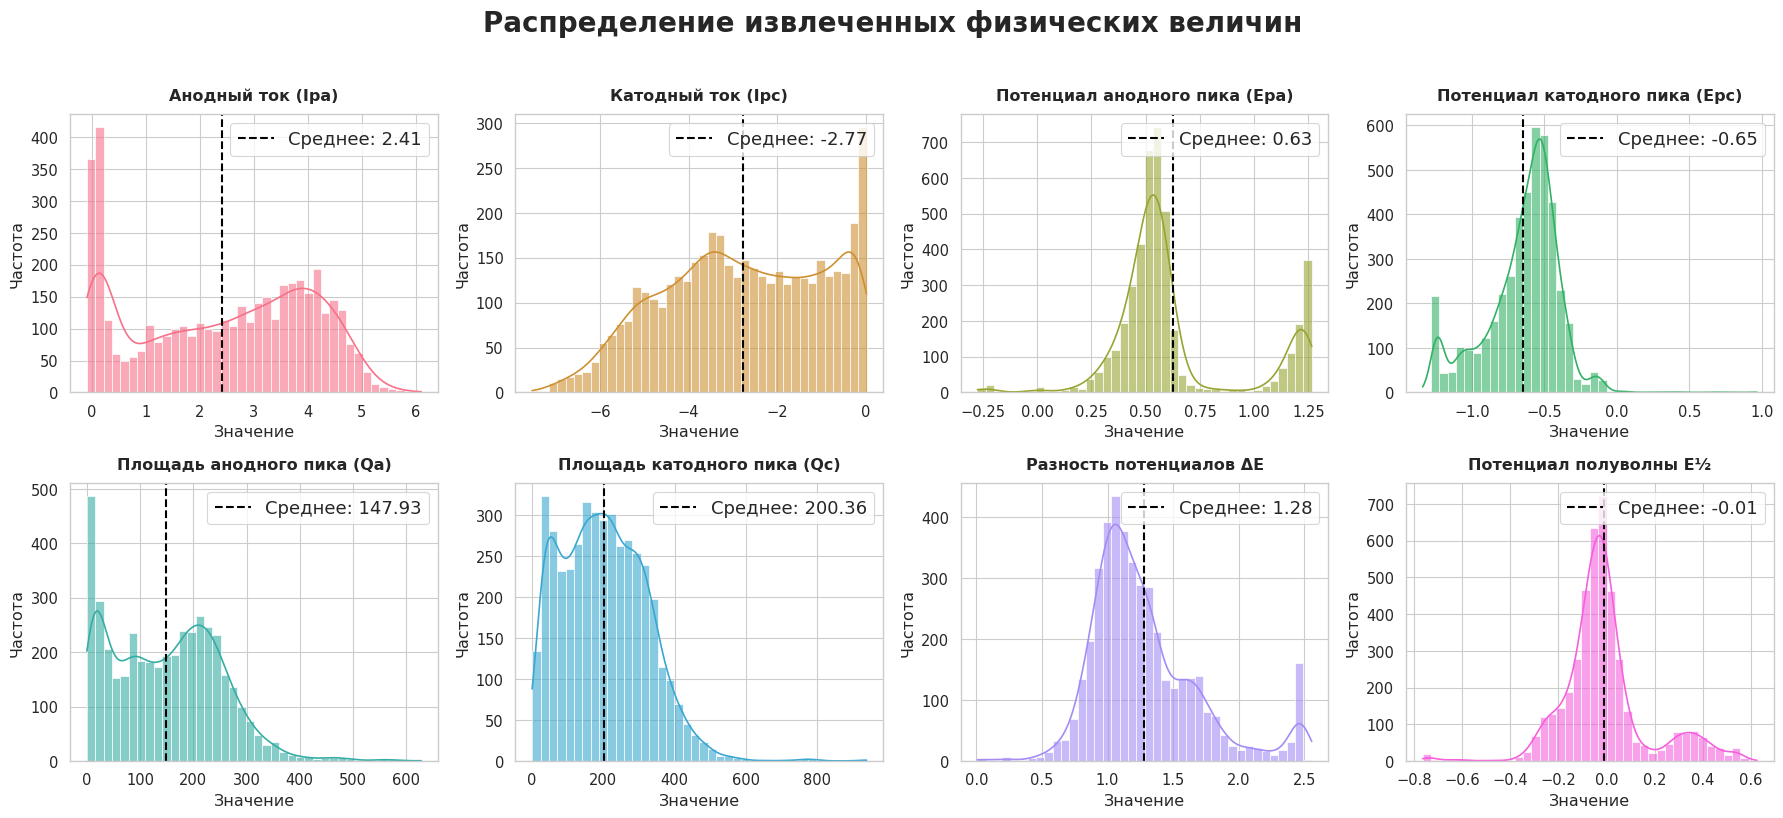

✅ График сохранен в: /mnt/c/Users/edtop/ITMO/THESIS_CV_DIFF/experiments/cva_plots/Loss_Targets_Distributions.png

 РЕКОМЕНДУЕМЫЕ ВЕСА ДЛЯ LOSS-ФУНКЦИИ (INVERSE SCALING)

Базовый масштаб (Токи): 2.588

w_heights       =   1.0000
w_positions     =   4.0374
w_areas         =   0.0149
w_delta_E       =   2.0249
w_half_wave     =  21.2041

[*] Скопируйте это в ваш метод forward():
--------------------------------------------------
w_heights = 1.0
w_positions = 4.04
w_areas = 0.01486
w_delta_E = 2.02
w_half_wave = 21.20
--------------------------------------------------


In [ ]:
print("[*] Извлечение параметров для анализа функции потерь...")
loss_analyzer = LossTargetAnalyzer(pipe.all_voltage, pipe.all_current)
loss_targets_df = loss_analyzer.extract_statistics()

print("\n=======================================================")
print(" СТАТИСТИКА ЦЕЛЕВЫХ ПЕРЕМЕННЫХ (ДЛЯ НАСТРОЙКИ ВЕСОВ LOSS)")
print("=======================================================\n")
display(loss_targets_df.describe().T)

sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")

param_names_ru = {
    'anodic_height': 'Анодный ток (Ipa)',
    'cathodic_height': 'Катодный ток (Ipc)',
    'anodic_pos': 'Потенциал анодного пика (Epa)',
    'cathodic_pos': 'Потенциал катодного пика (Epc)',
    'anodic_area': 'Площадь анодного пика (Qa)',
    'cathodic_area': 'Площадь катодного пика (Qc)',
    'delta_E': 'Разность потенциалов ΔE',
    'half_wave_potential': 'Потенциал полуволны E½'
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = sns.color_palette("husl", 8)

for i, col in enumerate(loss_targets_df.columns):
    sns.histplot(loss_targets_df[col], kde=True, ax=axes[i], color=colors[i], bins=40, alpha=0.6)
    
    axes[i].set_title(param_names_ru[col], fontweight='bold', pad=10) 
    axes[i].set_xlabel("Значение")
    axes[i].set_ylabel("Частота")
    
    mean_val = loss_targets_df[col].mean()
    axes[i].axvline(mean_val, color='black', linestyle='dashed', linewidth=1.5, 
                    label=f'Среднее: {mean_val:.2f}')
    axes[i].legend(loc='upper right', fontsize=13)

plt.suptitle("Распределение извлеченных физических величин", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
loss_dist_filename = SAVE_DIR / "Loss_Targets_Distributions.png"
plt.savefig(loss_dist_filename, dpi=300, bbox_inches='tight')
plt.show()
print(f"График сохранен в: {loss_dist_filename}")

print("\n=======================================================")
print(" РЕКОМЕНДУЕМЫЕ ВЕСА ДЛЯ LOSS-ФУНКЦИИ (INVERSE SCALING)")
print("=======================================================\n")

scale_height = (loss_targets_df['anodic_height'].abs().mean() + 
                loss_targets_df['cathodic_height'].abs().mean()) / 2.0

scale_pos = (loss_targets_df['anodic_pos'].abs().mean() + 
             loss_targets_df['cathodic_pos'].abs().mean()) / 2.0

scale_area = (loss_targets_df['anodic_area'].abs().mean() + 
              loss_targets_df['cathodic_area'].abs().mean()) / 2.0

scale_delta_E = loss_targets_df['delta_E'].abs().mean()

scale_half_wave = loss_targets_df['half_wave_potential'].abs().mean()
if scale_half_wave < 0.05:
    scale_half_wave = loss_targets_df['half_wave_potential'].std()

weights = {
    "w_heights": 1.0,
    "w_positions": scale_height / scale_pos,
    "w_areas": scale_height / scale_area,
    "w_delta_E": scale_height / scale_delta_E,
    "w_half_wave": scale_height / scale_half_wave
}

print(f"Базовый масштаб (Токи): {scale_height:.3f}\n")

for key, weight in weights.items():
    print(f"{key:<15} = {weight:>8.4f}")

print("\n[*] Скопируйте это в ваш метод forward():")
print("-" * 50)
print(f"""w_heights = {weights['w_heights']:.1f}
w_positions = {weights['w_positions']:.2f}
w_areas = {weights['w_areas']:.5f}
w_delta_E = {weights['w_delta_E']:.2f}
w_half_wave = {weights['w_half_wave']:.2f}""")
print("-" * 50)

/tmp/ipykernel_58650/3792324904.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([name_mapping[item] for item in order], rotation=20, ha='right')


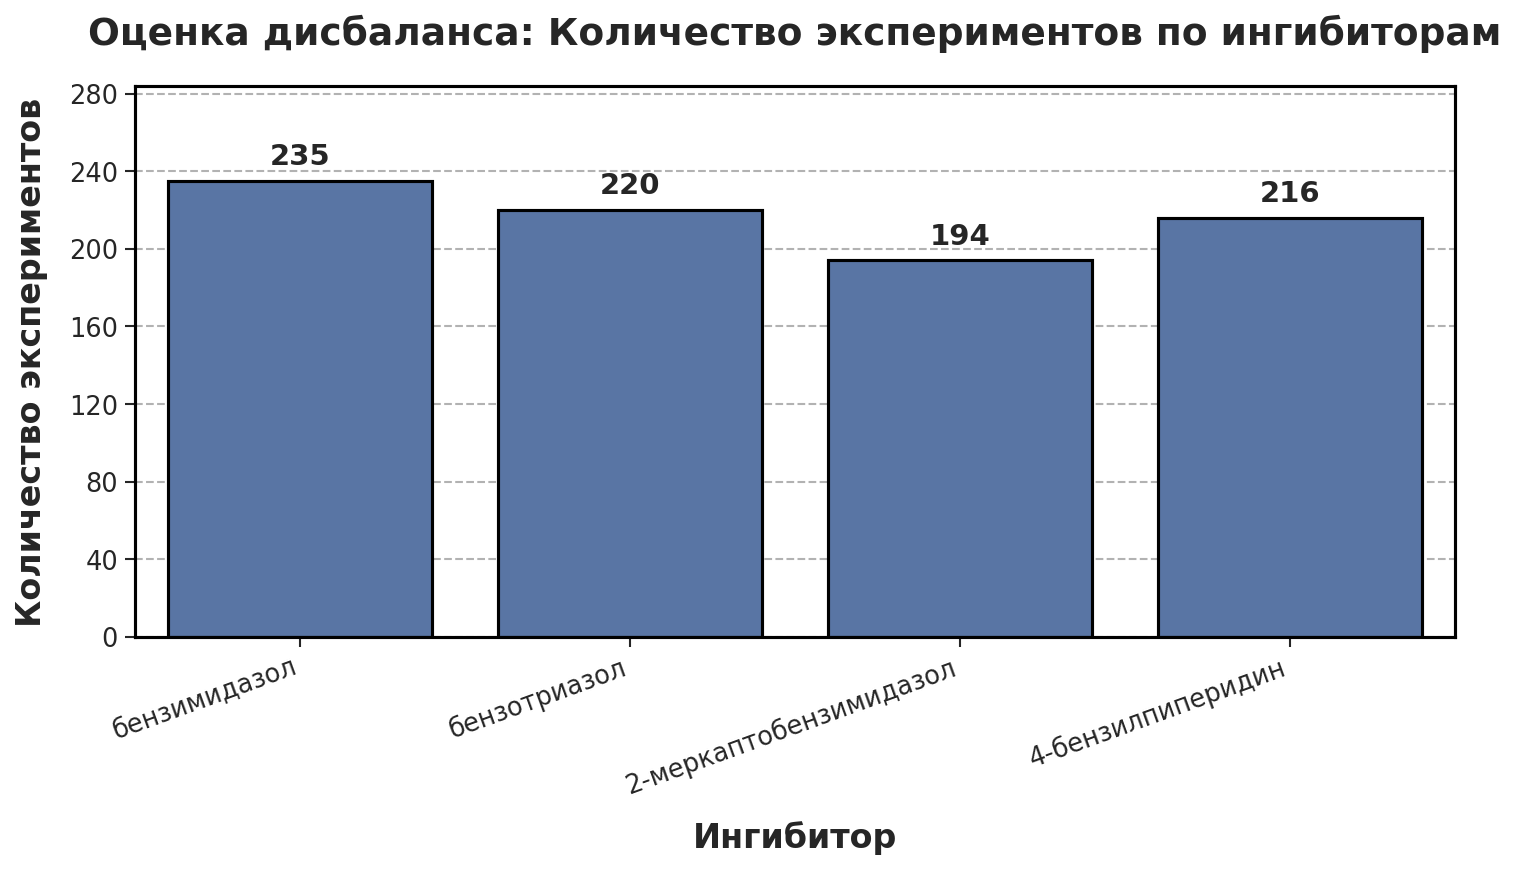

In [ ]:
name_mapping = {
    'benzimidazole': 'бензимидазол',
    'benzotriazole': 'бензотриазол',
    '2-mercaptobenzimidazole': '2-меркаптобензимидазол',
    '4-benzylpiperidine': '4-бензилпиперидин'
}

order = ['benzimidazole', 'benzotriazole', '2-mercaptobenzimidazole', '4-benzylpiperidine']

sns.set_theme(style="ticks", context="paper", font_scale=1.4)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

ax = sns.countplot(
    data=stats_with_meta, 
    x='Inhibitor', 
    order=order, 
    color='#4C72B0',         
    edgecolor='black',       
    linewidth=1.5,           
    ax=ax
)

y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max * 1.15)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x / 5)}"))

ax.set_xticklabels([name_mapping[item] for item in order], rotation=20, ha='right')

plt.title("Оценка дисбаланса: Количество экспериментов по ингибиторам", fontweight='bold', fontsize=18, pad=20)
plt.xlabel("Ингибитор", fontweight='bold', fontsize=16, labelpad=10)
plt.ylabel("Количество экспериментов", fontweight='bold', fontsize=16, labelpad=10)

for p in ax.patches:
    original_count = p.get_height()
    experiment_count = original_count / 5
    ax.annotate(
        f'{int(experiment_count)}', 
        (p.get_x() + p.get_width() / 2., original_count),
        ha='center', 
        va='bottom', 
        fontsize=14, 
        fontweight='bold',
        xytext=(0, 5),         
        textcoords='offset points'
    )

for spine in ax.spines.values():
    spine.set_color('black')    
    spine.set_linewidth(1.5)    

ax.yaxis.grid(True, linestyle='--', linewidth=1, alpha=0.6, color='gray', zorder=0)
ax.set_axisbelow(True) 

plt.tight_layout()
plt.show()

/tmp/ipykernel_58650/2277583471.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='Inhibitor', y='Count', order=order, palette='Set2')
/tmp/ipykernel_58650/2277583471.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([name_mapping[item] for item in order])


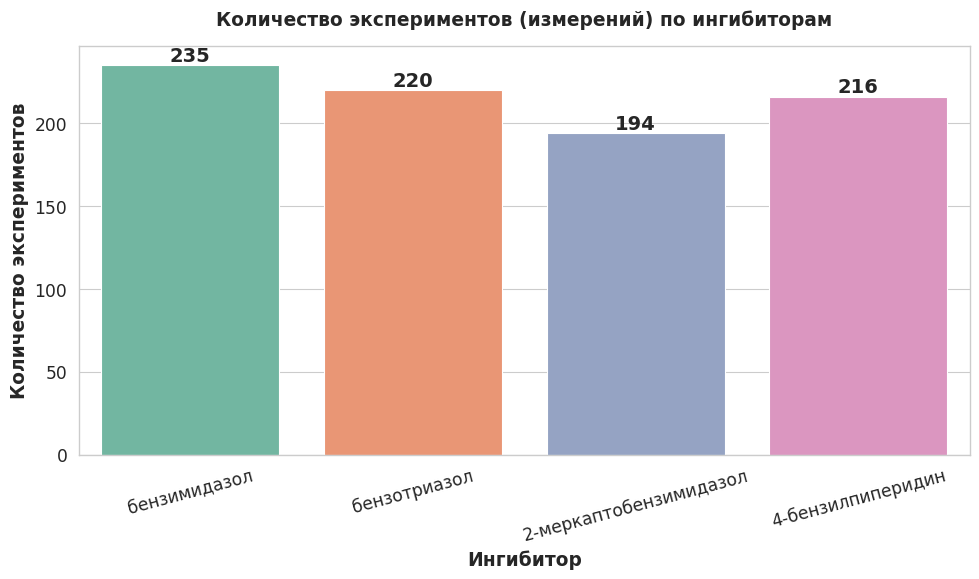

In [ ]:
name_mapping = {
    'benzimidazole': 'бензимидазол',
    'benzotriazole': 'бензотриазол',
    '2-mercaptobenzimidazole': '2-меркаптобензимидазол',
    '4-benzylpiperidine': '4-бензилпиперидин'
}

order = ['benzimidazole', 'benzotriazole', '2-mercaptobenzimidazole', '4-benzylpiperidine']

cycle_counts = stats_with_meta['Inhibitor'].value_counts().reindex(order, fill_value=0)

experiment_counts = cycle_counts / 5

plot_df = pd.DataFrame({'Inhibitor': experiment_counts.index, 'Count': experiment_counts.values})

sns.set_context("paper", font_scale=1.4)
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=plot_df, x='Inhibitor', y='Count', order=order, palette='Set2')

ax.set_xticklabels([name_mapping[item] for item in order])

plt.title("Количество экспериментов (измерений) по ингибиторам", fontweight='bold', pad=15)
plt.xlabel("Ингибитор", fontweight='bold')
plt.ylabel("Количество экспериментов", fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

[*] Отрисовка графиков по ингибиторам (Train)...
[*] Найдено ингибиторов для отрисовки: 3


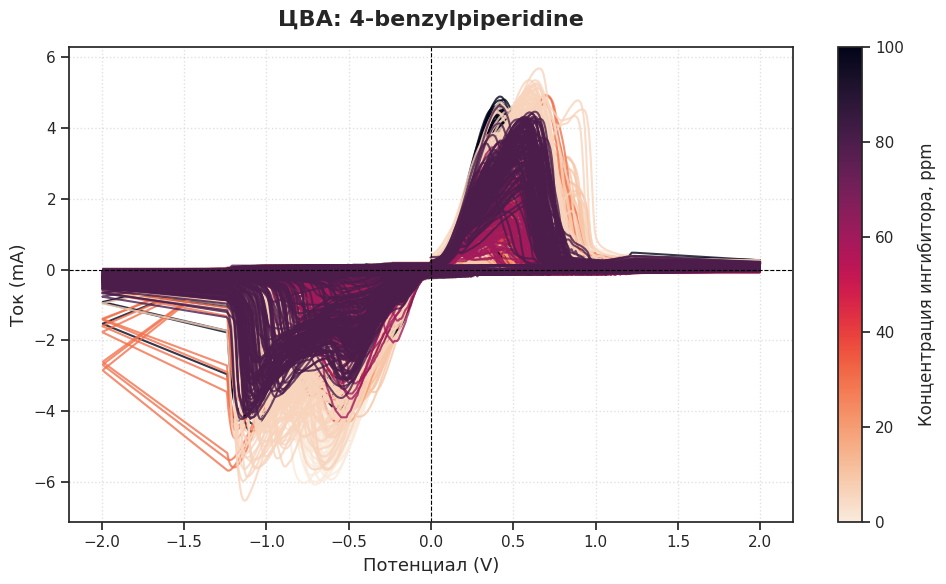

Сохранено: /mnt/c/Users/edtop/ITMO/THESIS_CV_DIFF/experiments/cva_plots/CVA_Trend_4-benzylpiperidine.png



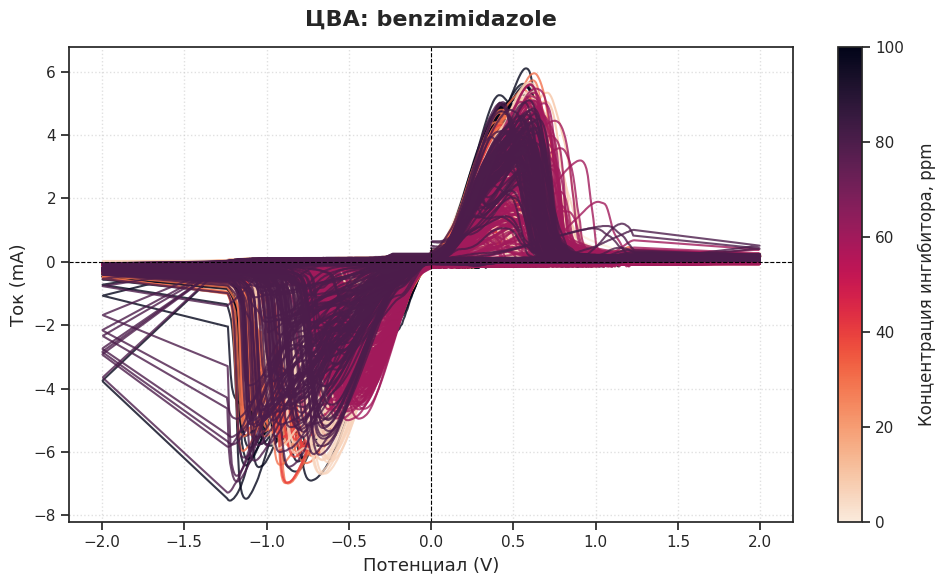

Сохранено: /mnt/c/Users/edtop/ITMO/THESIS_CV_DIFF/experiments/cva_plots/CVA_Trend_benzimidazole.png



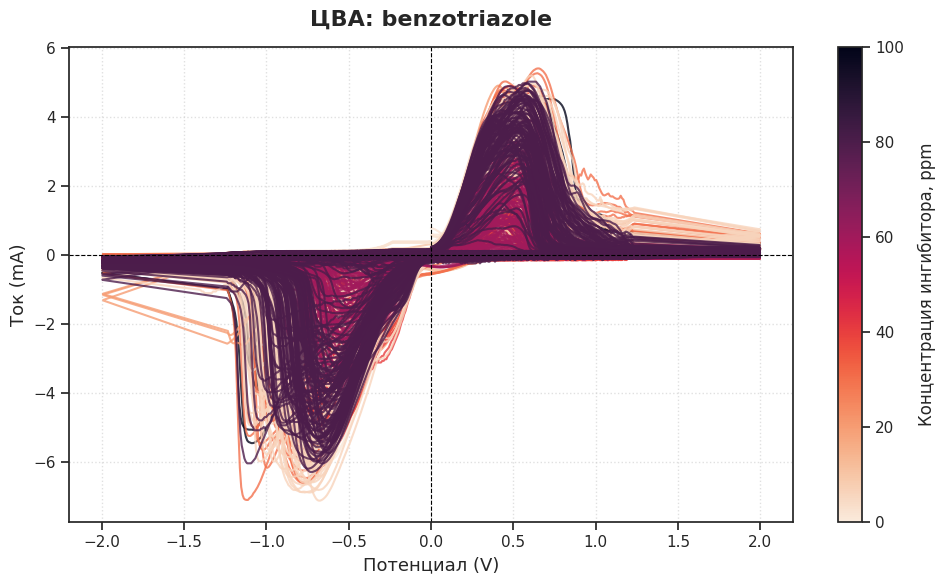

Сохранено: /mnt/c/Users/edtop/ITMO/THESIS_CV_DIFF/experiments/cva_plots/CVA_Trend_benzotriazole.png

[*] Отрисовка тестового ингибитора: 2-mercaptobenzimidazole...
[*] Найдено ингибиторов для отрисовки: 1


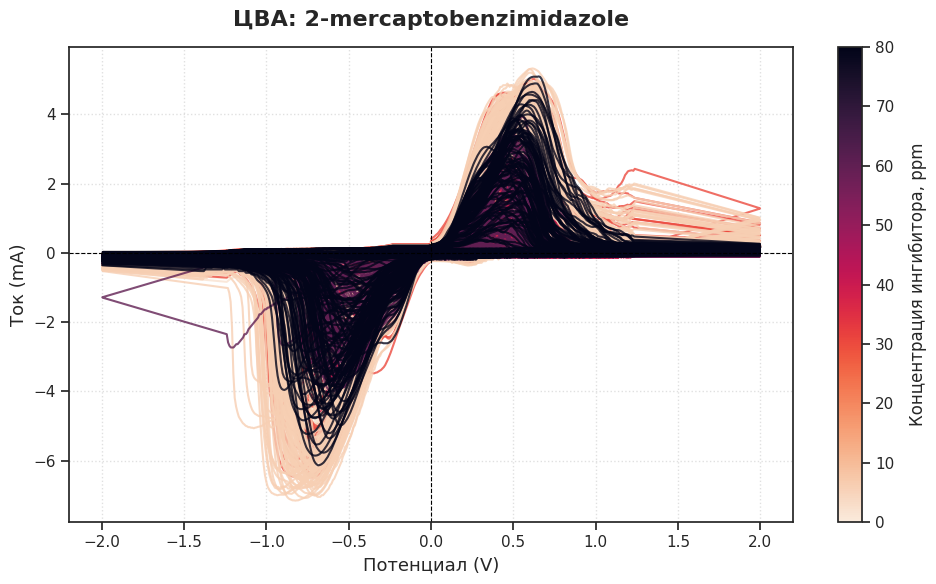

Сохранено: /mnt/c/Users/edtop/ITMO/THESIS_CV_DIFF/experiments/cva_plots/CVA_Trend_2-mercaptobenzimidazole.png



In [ ]:
def plot_cva_by_inhibitors(voltage_df, current_df, metadata_df, save_dir):
    sns.set_theme(style="ticks")
    
    unique_inhibitors = metadata_df['Inhibitor'].unique()
    
    print(f"[*] Найдено ингибиторов для отрисовки: {len(unique_inhibitors)}")
    
    for inhibitor in unique_inhibitors:
        plt.figure(figsize=(10, 6))
        
        mask = metadata_df['Inhibitor'] == inhibitor
        
        v_data = voltage_df[mask]
        c_data = current_df[mask]
        ppm_data = metadata_df.loc[mask, 'ppm'].values
        
        min_ppm, max_ppm = ppm_data.min(), ppm_data.max()
        norm = plt.Normalize(vmin=min_ppm, vmax=max_ppm)
        cmap = sns.color_palette("rocket_r", as_cmap=True) 
        
        for i in range(len(v_data)):
            v = v_data.iloc[i].values
            c = c_data.iloc[i].values
            p = ppm_data[i]
            
            color = cmap(norm(p))
            
            plt.plot(v, c, color=color, linewidth=1.5, alpha=0.8)
        
        plt.title(f"ЦВА: {inhibitor}", fontsize=16, fontweight='bold', pad=15)
        plt.xlabel("Потенциал (V)", fontsize=13)
        plt.ylabel("Ток (mA)", fontsize=13)
        
        plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
        plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
        
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=plt.gca())
        cbar.set_label('Концентрация ингибитора, ppm', fontsize=12, labelpad=10)
        
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        
        safe_name = str(inhibitor).replace(' ', '_').replace('/', '_')
        filename = save_dir / f"CVA_Trend_{safe_name}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Сохранено: {filename}\n")

print("[*] Отрисовка графиков по ингибиторам (Train)...")
plot_cva_by_inhibitors(pipe.train_voltage, pipe.train_current, pipe.train_metadata, SAVE_DIR)

if pipe.test_inhibitor and pipe.test_metadata is not None:
    print(f"[*] Отрисовка тестового ингибитора: {TEST_INHIBITOR}...")
    plot_cva_by_inhibitors(pipe.test_voltage, pipe.test_current, pipe.test_metadata, SAVE_DIR)

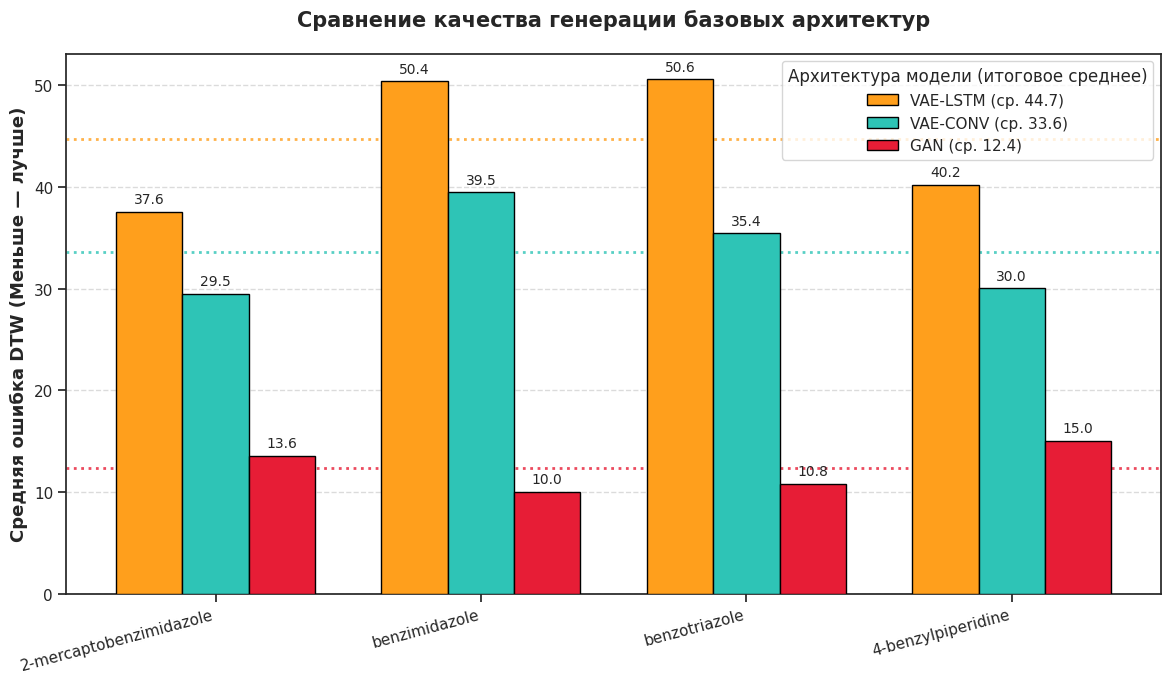

In [ ]:
inhibitors = [
    '2-mercaptobenzimidazole', 
    'benzimidazole', 
    'benzotriazole', 
    '4-benzylpiperidine'
]

dtw_vae_lstm = [37.5683, 50.4017, 50.5623, 40.2252]
dtw_vae_conv = [29.4947, 39.4656, 35.4398, 30.0146]
dtw_gan      = [13.5529, 10.0185, 10.8312, 15.0321]

mean_lstm = np.mean(dtw_vae_lstm)
mean_conv = np.mean(dtw_vae_conv)
mean_gan = np.mean(dtw_gan)

x = np.arange(len(inhibitors))  
width = 0.25                  

fig, ax = plt.subplots(figsize=(12, 7))
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

rects1 = ax.bar(x - width, dtw_vae_lstm, width, 
                label=f'VAE-LSTM (ср. {mean_lstm:.1f})', color='#FF9F1C', edgecolor='black', zorder=3)
rects2 = ax.bar(x, dtw_vae_conv, width, 
                label=f'VAE-CONV (ср. {mean_conv:.1f})', color='#2EC4B6', edgecolor='black', zorder=3)
rects3 = ax.bar(x + width, dtw_gan, width, 
                label=f'GAN (ср. {mean_gan:.1f})', color='#E71D36', edgecolor='black', zorder=3)

ax.axhline(mean_lstm, color='#FF9F1C', linestyle=':', linewidth=2, zorder=2, alpha=0.8)
ax.axhline(mean_conv, color='#2EC4B6', linestyle=':', linewidth=2, zorder=2, alpha=0.8)
ax.axhline(mean_gan, color='#E71D36', linestyle=':', linewidth=2, zorder=2, alpha=0.8)

ax.set_ylabel('Средняя ошибка DTW (Меньше — лучше)', fontsize=13, fontweight='bold')
ax.set_title('Сравнение качества генерации базовых архитектур', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(inhibitors, fontsize=11, rotation=15, ha='right')

ax.legend(fontsize=11, title='Архитектура модели (итоговое среднее)', title_fontsize='12')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()